# LSI (Latent Semantic Indexing)

In [1]:
from pathlib import Path
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from gensim import corpora, models
from gensim.models import CoherenceModel

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for p in (OUTPUT_DIR, MODELS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(SRC_DIR))

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis


## 1. Загрузка предобработанных данных

In [2]:
df = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
# В 01_data_preprocessing.ipynb токены сохранены как строка через пробел: "слово1 слово2..."
df["tokens"] = df["tokens"].apply(lambda x: x.split() if isinstance(x, str) else x)

dictionary = corpora.Dictionary.load(str(MODELS_DIR / "gensim_dictionary.dict"))
corpus_bow = list(corpora.MmCorpus(str(MODELS_DIR / "gensim_corpus.mm")))
texts = df["tokens"].tolist()

print(f"Документов: {len(df)}")
print(f"Размер словаря: {len(dictionary)}")

Документов: 6385
Размер словаря: 10000


## 2. Построение TF-IDF корпуса

In [3]:
tfidf = models.TfidfModel(corpus_bow)
corpus_tfidf = list(tfidf[corpus_bow])

tfidf.save(str(MODELS_DIR / "tfidf_model.model"))
print("TF-IDF модель сохранена:", MODELS_DIR / "tfidf_model.model")

TF-IDF модель сохранена: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\models\tfidf_model.model


## 3. Подбор оптимального числа тем

In [4]:
num_topics_range = [5, 10, 15, 20, 25, 30, 40, 50]
lsi_results = []

for num_topics in tqdm(num_topics_range, desc="LSI: перебор числа тем"):
    try:
        lsi = models.LsiModel(
            corpus_tfidf,
            id2word=dictionary,
            num_topics=num_topics,
        )
        coherence = CoherenceModel(
            model=lsi, texts=texts, dictionary=dictionary, coherence="c_v"
        ).get_coherence()

        lsi_results.append({"num_topics": num_topics, "coherence": coherence})

    except Exception as e:
        print(f"Ошибка [{num_topics} тем]: {e}")

lsi_results_df = (
    pd.DataFrame(lsi_results)
    .sort_values("coherence", ascending=False)
    .reset_index(drop=True)
)
lsi_results_df.to_csv(OUTPUT_DIR / "lsi_optimization_results.csv", index=False)

print("\nРезультаты LSI оптимизации:")
print(lsi_results_df.to_string(index=False))

LSI: перебор числа тем: 100%|██████████| 8/8 [02:45<00:00, 20.69s/it]


Результаты LSI оптимизации:
 num_topics  coherence
          5   0.579470
         10   0.466736
         15   0.402789
         20   0.349177
         25   0.341158
         30   0.335973
         40   0.329058
         50   0.317165


## 4. Визуализация: когерентность vs число тем

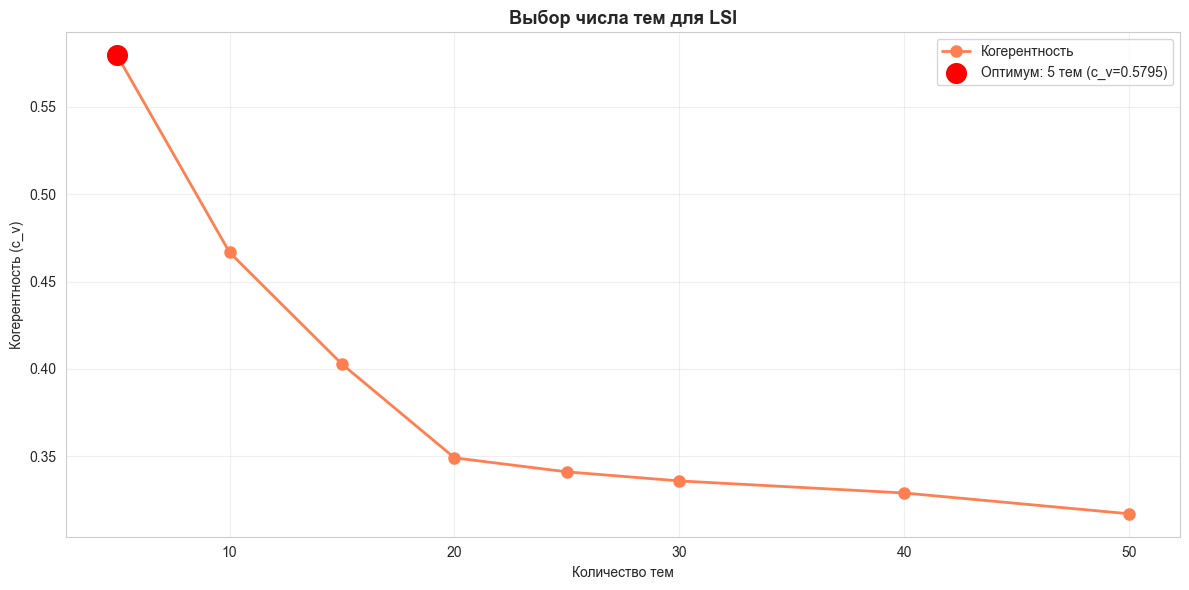

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\lsi_optimization.png


In [5]:
# Для графика нужен порядок по числу тем, не по когерентности
plot_df = lsi_results_df.sort_values("num_topics")

best_row = lsi_results_df.iloc[0]
best_num_topics  = int(best_row["num_topics"])
best_coherence   = best_row["coherence"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_df["num_topics"], plot_df["coherence"],
        marker="o", linewidth=2, markersize=8, color="coral", label="Когерентность")
ax.scatter(best_num_topics, best_coherence,
           color="red", s=200, zorder=5,
           label=f"Оптимум: {best_num_topics} тем (c_v={best_coherence:.4f})")
ax.set_xlabel("Количество тем")
ax.set_ylabel("Когерентность (c_v)")
ax.set_title("Выбор числа тем для LSI", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lsi_optimization.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "lsi_optimization.png")

## 5. Обучение финальной модели

In [6]:
print(f"Обучение финальной LSI модели: {best_num_topics} тем")

final_lsi = models.LsiModel(
    corpus_tfidf,
    id2word=dictionary,
    num_topics=best_num_topics,
)

final_lsi.save(str(MODELS_DIR / "lsi_model_best.model"))
print("Модель сохранена:", MODELS_DIR / "lsi_model_best.model")

Обучение финальной LSI модели: 5 тем
Модель сохранена: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\models\lsi_model_best.model


## 6. Просмотр тем финальной модели

In [7]:
print(f"Темы финальной LSI модели (top-10 слов):")
for idx, topic in final_lsi.show_topics(
    num_topics=min(best_num_topics, 15), num_words=10, formatted=False
):
    words = " + ".join(f"{w}({s:.3f})" for w, s in topic)
    print(f"  Тема {idx + 1}: {words}")

Темы финальной LSI модели (top-10 слов):
  Тема 1: оператор(0.186) + уравнение(0.173) + группа(0.150) + пространство(0.115) + поле(0.101) + функция(0.101) + матрица(0.098) + наз(0.098) + система(0.096) + неравенство(0.092)
  Тема 2: казань(-0.257) + редакция(-0.187) + отпечатать(-0.184) + редактор(-0.182) + факс(-0.182) + макет(-0.179) + цена(-0.168) + оригинал(-0.166) + тело(-0.150) + университетский(-0.149)
  Тема 3: группа(-0.366) + кольцо(-0.204) + алгебра(-0.198) + оператор(0.194) + уравнение(0.175) + оценка(0.153) + поле(-0.150) + неравенство(0.148) + подгруппа(-0.125) + многообразие(-0.124)
  Тема 4: оператор(0.381) + распределение(-0.221) + случайный(-0.203) + вероятность(-0.143) + частица(-0.138) + процесс(-0.129) + модель(-0.128) + неравенство(0.118) + состояние(-0.110) + квантовый(-0.109)
  Тема 5: поверхность(-0.243) + уравнение(-0.217) + кольцо(0.154) + случайный(0.149) + частица(-0.139) + тензор(-0.128) + кривизна(-0.127) + алгебра(0.123) + квантовый(-0.119) + оценка(0.11

## 7. Визуализация тем

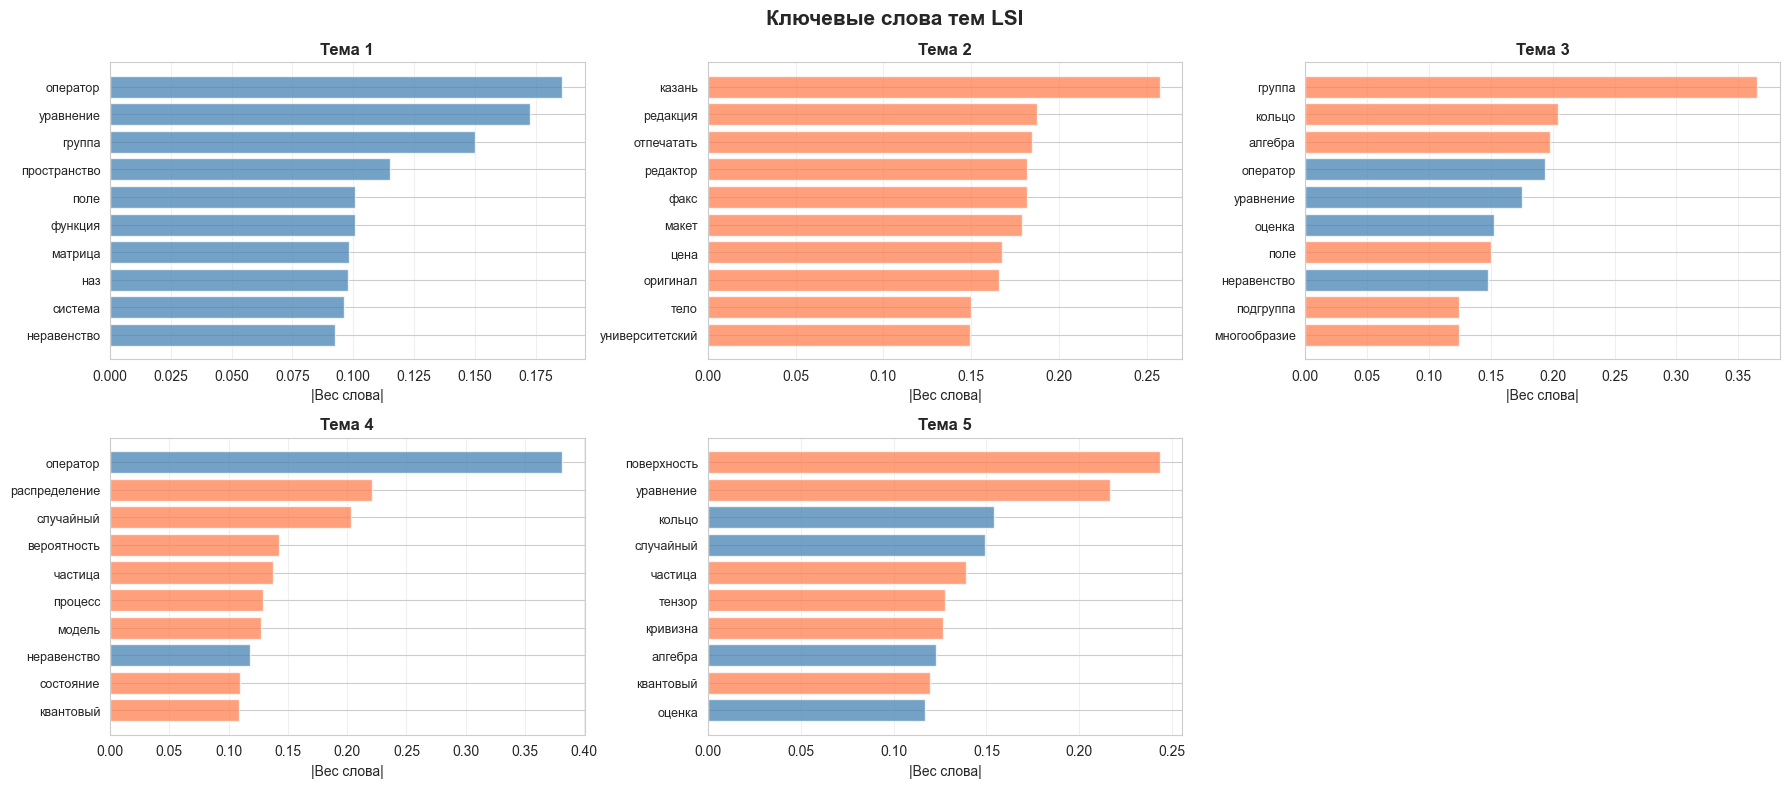

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\lsi_topics.png


In [8]:
show_n = min(best_num_topics, 15)
cols = 3
rows = (show_n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for idx, topic in final_lsi.show_topics(
    num_topics=show_n, num_words=10, formatted=False
):
    words = [w for w, _ in topic]
    scores = [abs(s) for _, s in topic]  # LSI может давать отрицательные веса
    colors = ["steelblue" if s >= 0 else "coral" for _, s in topic]
    ax = axes[idx]
    ax.barh(range(len(words)), scores, color=colors, alpha=0.75)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("|Вес слова|")
    ax.set_title(f"Тема {idx + 1}", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

for j in range(show_n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Ключевые слова тем LSI", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lsi_topics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "lsi_topics.png")

## 8. Итоговые метрики качества

In [9]:
coherence_cv = CoherenceModel(
    model=final_lsi, texts=texts, dictionary=dictionary, coherence="c_v"
).get_coherence()

coherence_umass = CoherenceModel(
    model=final_lsi, texts=texts, dictionary=dictionary, coherence="u_mass"
).get_coherence()

print("Метрики финальной LSI модели")
print(f"  Когерентность c_v:    {coherence_cv:.4f}")
print(f"  Когерентность u_mass: {coherence_umass:.4f}")
print(f"  Число тем:            {final_lsi.num_topics}")

pd.DataFrame([{
    "model": "LSI",
    "num_topics": final_lsi.num_topics,
    "coherence_cv": coherence_cv,
    "coherence_umass": coherence_umass,
    "perplexity": None,
}]).to_csv(OUTPUT_DIR / "lsi_final_metrics.csv", index=False)
print("Метрики сохранены:", OUTPUT_DIR / "lsi_final_metrics.csv")

Метрики финальной LSI модели
  Когерентность c_v:    0.4109
  Когерентность u_mass: -1.2990
  Число тем:            5
Метрики сохранены: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\lsi_final_metrics.csv
